# Задание 3. Метод k-ближайших соседей

Что нужно сделать:
- вручную написать метод k-ближайших соседей с двумя гиперпараметрами: метрика расстояния и число соседей `k`;
- пройти на нем всю последовательность шагов задачи классификации на датасете `load_iris`;
- на датасете `breast cancer` обучить готовый `KNeighborsClassifier`, построить график точности от `k` для k = 1..30
  и 2D карту границы классификации;
- на датасете `house` обучить `KNeighborsRegressor`, предсказать цену дома и построить график MAE от `k`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

np.random.seed(42)

## Часть 1. Своя реализация k-ближайших соседей (датасет iris)

Идея метода: у нового объекта считаем расстояние до всех объектов обучающей выборки, берем `k` самых близких
и смотрим, какой класс среди них встречается чаще — он и будет ответом. Никакого обучения как такого нет,
модель просто запоминает обучающую выборку.

Гиперпараметры:
- **метрика** — как считать расстояние между объектами;
- **k** — сколько соседей учитывать.

### Шаг 1. Загружаем данные и смотрим на них

In [2]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["target"] = iris.target
iris_df["class"] = [iris.target_names[i] for i in iris.target]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
iris_df.info()
print()
print(iris_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   class              150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
class                0
dtype: int64


In [4]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# классы сбалансированы — по 50 объектов на каждый
iris_df["class"].value_counts()

class
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Шаг 2. Делим выборку на обучающую и тестовую

Делим со стратификацией, чтобы в тесте оказались все три класса примерно в тех же пропорциях.

In [6]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("обучающая:", X_train.shape, " тестовая:", X_test.shape)

обучающая: (105, 4)  тестовая: (45, 4)


### Шаг 3. Масштабируем признаки

kNN работает на расстояниях, поэтому признак с большим разбросом перетягивает расстояние на себя.
Приводим все признаки к одному масштабу: $x_{norm} = (x - mean)/std$. Параметры считаем **только по
обучающей выборке**, иначе информация о тесте протечет в обучение.

In [7]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_n = (X_train - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

### Шаг 4. Пишем сам метод

In [8]:
# расстояние между двумя объектами, метрика — гиперпараметр
def distance(a, b, metric):
    if metric == "euclidean":
        return np.sqrt(np.sum((a - b) ** 2))
    if metric == "manhattan":
        return np.sum(np.abs(a - b))
    if metric == "chebyshev":
        return np.max(np.abs(a - b))

In [9]:
# k-ближайшие соседи вручную: для каждого тестового объекта ищем k ближайших и голосуем
def knn_predict(X_train, y_train, X_test, k, metric):
    y_pred = []

    for x in X_test:
        dists = []
        for x_tr in X_train:
            dists.append(distance(x, x_tr, metric))

        nearest = np.argsort(dists)[:k]        # индексы k ближайших соседей
        classes = y_train[nearest]            # их классы
        votes = np.bincount(classes)          # сколько голосов у каждого класса
        y_pred.append(np.argmax(votes))       # побеждает самый частый

    return np.array(y_pred)

### Шаг 5. Обучаем (запоминаем выборку) и делаем прогноз

In [10]:
y_pred = knn_predict(X_train_n, y_train, X_test_n, k=5, metric="euclidean")

pd.DataFrame({
    "правильный ответ": [iris.target_names[i] for i in y_test][:10],
    "прогноз": [iris.target_names[i] for i in y_pred][:10],
})

,правильный ответ,прогноз
0,virginica,virginica
1,versicolor,versicolor
2,virginica,versicolor
3,versicolor,versicolor
4,virginica,virginica
5,virginica,virginica
6,versicolor,versicolor
7,versicolor,versicolor
8,setosa,setosa
9,virginica,virginica


### Шаг 6. Считаем метрики качества

In [11]:
# метрики классификации, чтобы не писать их несколько раз
def print_metrics(y_true, y_pred):
    print("Accuracy  =", accuracy_score(y_true, y_pred))
    print("Precision =", precision_score(y_true, y_pred, average="macro"))
    print("Recall    =", recall_score(y_true, y_pred, average="macro"))
    print("F1        =", f1_score(y_true, y_pred, average="macro"))

In [12]:
print("--- своя реализация, k = 5, euclidean ---")
print_metrics(y_test, y_pred)

--- своя реализация, k = 5, euclidean ---
Accuracy  = 0.9111111111111111
Precision = 0.9298245614035089
Recall    = 0.9111111111111111
F1        = 0.9095022624434389


In [13]:
# матрица ошибок: по строкам правильные классы, по столбцам предсказанные
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names)

,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,15,0
virginica,0,4,11


Из 45 тестовых объектов модель ошиблась на 4, accuracy = 0.91. Все ошибки одного типа: virginica принята за
versicolor. Setosa отделяется идеально (ни одной ошибки), а versicolor и virginica в пространстве признаков
соприкасаются, и соседи на границе оказываются из чужого класса.

### Шаг 7. Подбираем гиперпараметры: метрику и k

In [14]:
metrics_list = ["euclidean", "manhattan", "chebyshev"]
k_values = range(1, 31)

acc_by_metric = {}

for metric in metrics_list:
    accs = []
    for k in k_values:
        pred = knn_predict(X_train_n, y_train, X_test_n, k, metric)
        accs.append(accuracy_score(y_test, pred))
    acc_by_metric[metric] = accs
    print(metric, ": лучшая accuracy =", max(accs), " при k =", np.argmax(accs) + 1)

euclidean : лучшая accuracy = 0.9555555555555556  при k = 9
manhattan : лучшая accuracy = 0.9333333333333333  при k = 1
chebyshev : лучшая accuracy = 0.9333333333333333  при k = 9


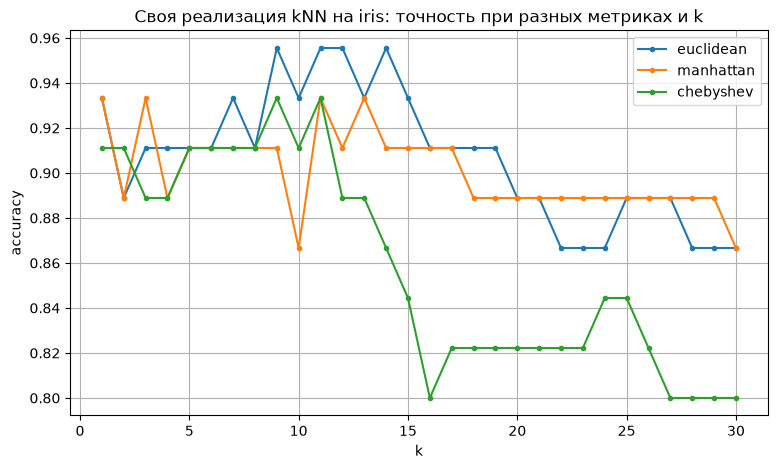

In [15]:
plt.figure(figsize=(9, 5))
for metric in metrics_list:
    plt.plot(k_values, acc_by_metric[metric], marker=".", label=metric)

plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("Своя реализация kNN на iris: точность при разных метриках и k")
plt.legend()
plt.grid(True)
plt.show()

Лучше всех отработало евклидово расстояние: максимум accuracy = 0.956 при k = 9. Манхэттенское держится чуть
ниже (максимум 0.933), а расстояние Чебышева на больших `k` заметно проседает — до 0.78, потому что оно смотрит
только на один самый "разошедшийся" признак и теряет информацию из остальных.

По самому `k` картина одинаковая у всех метрик: при маленьком `k` модель слишком чувствительна к отдельным
объектам, при большом начинает набирать в соседи объекты чужого класса и точность падает. Лучшие значения
получаются в середине диапазона, примерно k = 9-15.

### Шаг 8. Сверяем свою реализацию с sklearn

In [16]:
model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
model.fit(X_train_n, y_train)
pred_sk = model.predict(X_test_n)

print("своя реализация: accuracy =", accuracy_score(y_test, knn_predict(X_train_n, y_train, X_test_n, 5, "euclidean")))
print("sklearn:         accuracy =", accuracy_score(y_test, pred_sk))
print("прогнозы совпадают полностью:", np.array_equal(y_pred, pred_sk))

своя реализация: accuracy = 0.9111111111111111
sklearn:         accuracy = 0.9111111111111111
прогнозы совпадают полностью: True


Прогнозы своей реализации и `KNeighborsClassifier` совпали объект в объект — значит метод написан правильно.

### Шаг 9. 2D карта границы классификации (своя реализация)

Чтобы нарисовать границу, нужно всего 2 признака — берем длину и ширину чашелистика. Дальше покрываем плоскость
сеткой точек, прогоняем каждую точку через свою реализацию kNN и раскрашиваем фон в цвет предсказанного класса.

In [17]:
from matplotlib.colors import ListedColormap

X2 = iris.data[:, :2]      # sepal length, sepal width

k = 15
step = 0.05
x_min, x_max = X2[:, 0].min() - 0.2, X2[:, 0].max() + 0.2
y_min, y_max = X2[:, 1].min() - 0.2, X2[:, 1].max() + 0.2

xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                     np.arange(y_min, y_max, step))
grid = np.c_[xx.ravel(), yy.ravel()]

zz = knn_predict(X2, y, grid, k=k, metric="euclidean")
zz = zz.reshape(xx.shape)

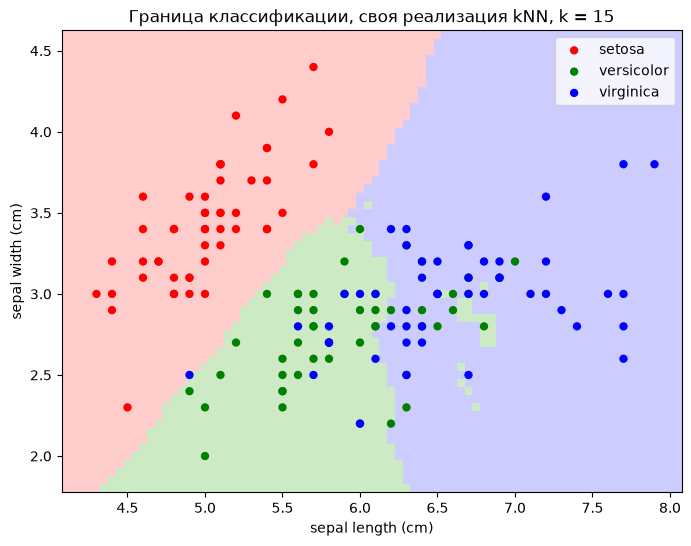

In [18]:
cmap_back = ListedColormap(["#ffcccc", "#ccebc5", "#ccccff"])
colors = ["red", "green", "blue"]

plt.figure(figsize=(8, 6))
plt.pcolormesh(xx, yy, zz, cmap=cmap_back, shading="auto")

for i, name in enumerate(iris.target_names):
    plt.scatter(X2[y == i, 0], X2[y == i, 1], c=colors[i], label=name, edgecolors="none")

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Граница классификации, своя реализация kNN, k = " + str(k))
plt.legend()
plt.show()

Область setosa отделена от остальных чистой границей — этот класс легко отличить по двум признакам.
А вот versicolor и virginica перемешаны, и граница между ними получается рваной, с "островками" внутри чужой
области: только по чашелистику эти два вида не разделяются.

## Часть 2. Готовый KNeighborsClassifier на датасете breast cancer

Теперь задача бинарная: по 30 признакам определить, доброкачественная опухоль или злокачественная.

In [19]:
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
cancer_df["target"] = cancer.target
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [20]:
print(cancer_df.shape)
print(cancer.target_names)          # 0 — malignant, 1 — benign
print(cancer_df["target"].value_counts())
print("пропусков:", cancer_df.isnull().sum().sum())

(569, 31)
['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64
пропусков: 0


In [21]:
# признаки в очень разных масштабах: площадь измеряется сотнями, а гладкость — сотыми долями
cancer_df[["mean radius", "mean area", "mean smoothness"]].describe()

,mean radius,mean area,mean smoothness
count,569.000000,569.000000,569.000000
mean,14.127292,654.889104,0.096360
std,3.524049,351.914129,0.014064
min,6.981000,143.500000,0.052630
25%,11.700000,420.300000,0.086370
50%,13.370000,551.100000,0.095870
75%,15.780000,782.700000,0.105300
max,28.110000,2501.000000,0.163400


In [22]:
Xc = cancer.data
yc = cancer.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.3, random_state=42, stratify=yc)

# масштабирование опять считаем только по обучающей части
Xc_mean = Xc_train.mean(axis=0)
Xc_std = Xc_train.std(axis=0)

Xc_train_n = (Xc_train - Xc_mean) / Xc_std
Xc_test_n = (Xc_test - Xc_mean) / Xc_std

print(Xc_train.shape, Xc_test.shape)

(398, 30) (171, 30)


### График зависимости точности от k

Считаем accuracy на тестовой выборке для k = 1..30. Заодно посмотрим, что будет без масштабирования признаков —
для kNN это принципиальный момент.

In [23]:
k_values = range(1, 31)
acc_raw = []
acc_scaled = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xc_train, yc_train)
    acc_raw.append(accuracy_score(yc_test, model.predict(Xc_test)))

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xc_train_n, yc_train)
    acc_scaled.append(accuracy_score(yc_test, model.predict(Xc_test_n)))

print("без масштабирования: лучшая accuracy =", max(acc_raw), " при k =", np.argmax(acc_raw) + 1)
print("с масштабированием:  лучшая accuracy =", max(acc_scaled), " при k =", np.argmax(acc_scaled) + 1)

без масштабирования: лучшая accuracy = 0.9415204678362573  при k = 9
с масштабированием:  лучшая accuracy = 0.9766081871345029  при k = 12


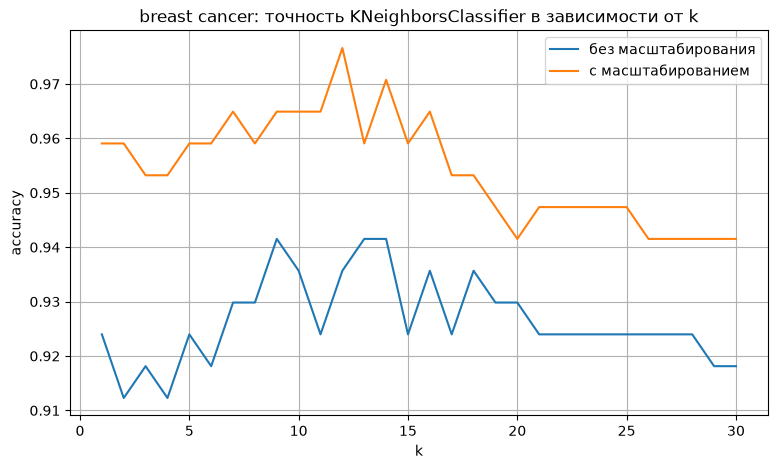

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, acc_raw, label="без масштабирования")
plt.plot(k_values, acc_scaled, label="с масштабированием")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("breast cancer: точность KNeighborsClassifier в зависимости от k")
plt.legend()
plt.grid(True)
plt.show()

На сырых признаках точность колеблется в узком коридоре 0.91-0.94 и от `k` почти не зависит: расстояние
определяется практически целиком признаком `mean area` (он на два порядка больше остальных), а вклад остальных
29 признаков в сумму теряется. После масштабирования вся кривая поднимается на 3-4 процентных пункта — от 0.94
до 0.977, максимум при k = 12. То есть для kNN нормировка признаков дает больше, чем подбор `k`: даже худшее `k`
на масштабированных данных лучше, чем лучшее `k` на сырых.

### Метрики для лучшего k

In [25]:
best_k = int(np.argmax(acc_scaled)) + 1

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(Xc_train_n, yc_train)
pred_c = model.predict(Xc_test_n)

print("k =", best_k)
print_metrics(yc_test, pred_c)

k = 12
Accuracy  = 0.9766081871345029
Precision = 0.9819819819819819
Recall    = 0.96875
F1        = 0.97469665581533


In [26]:
cm = confusion_matrix(yc_test, pred_c)
pd.DataFrame(cm, index=cancer.target_names, columns=cancer.target_names)

,malignant,benign
malignant,60,4
benign,0,107


Ошибок всего 4 из 171, и все они одного типа: злокачественную опухоль модель приняла за доброкачественную.
Обратных ошибок нет вообще. В медицинской задаче пропустить злокачественную опухоль — это как раз самая
неприятная ошибка, поэтому здесь важнее смотреть не на accuracy, а на recall для класса malignant.

### 2D карта границы классификации

Для карты обучим модель на двух признаках — `mean radius` и `mean texture`.

In [27]:
f1_idx, f2_idx = 0, 1        # mean radius, mean texture
Xc2 = Xc[:, [f1_idx, f2_idx]]

# те же шаги: сначала делим, потом масштабируем по обучающей части
Xc2_train, Xc2_test, yc2_train, yc2_test = train_test_split(
    Xc2, yc, test_size=0.3, random_state=42, stratify=yc)

m2 = Xc2_train.mean(axis=0)
s2 = Xc2_train.std(axis=0)

model2 = KNeighborsClassifier(n_neighbors=15)
model2.fit((Xc2_train - m2) / s2, yc2_train)

print("accuracy на 2 признаках =", accuracy_score(yc2_test, model2.predict((Xc2_test - m2) / s2)))

accuracy на 2 признаках = 0.9005847953216374


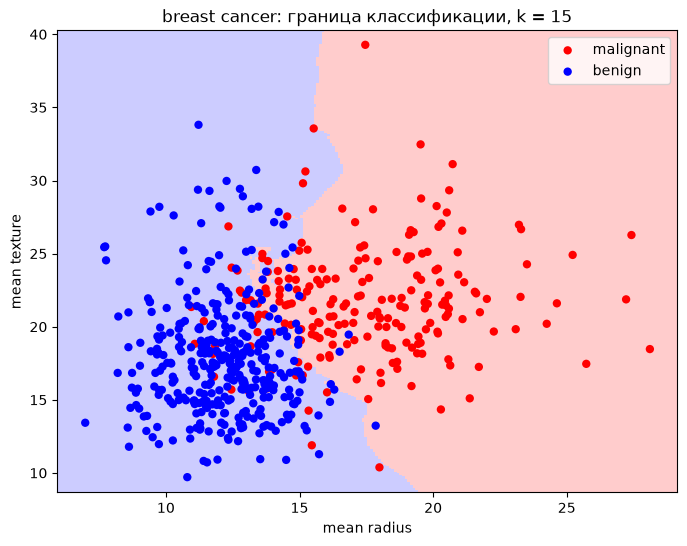

In [28]:
x_min, x_max = Xc2[:, 0].min() - 1, Xc2[:, 0].max() + 1
y_min, y_max = Xc2[:, 1].min() - 1, Xc2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

grid = np.c_[xx.ravel(), yy.ravel()]
zz = model2.predict((grid - m2) / s2).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xx, yy, zz, cmap=ListedColormap(["#ffcccc", "#ccccff"]), shading="auto")

for i, name in enumerate(cancer.target_names):
    plt.scatter(Xc2[yc == i, 0], Xc2[yc == i, 1], c=["red", "blue"][i], label=name, edgecolors="none")

plt.xlabel(cancer.feature_names[f1_idx])
plt.ylabel(cancer.feature_names[f2_idx])
plt.title("breast cancer: граница классификации, k = 15")
plt.legend()
plt.show()

Граница идет почти вертикально: класс определяется в первую очередь радиусом опухоли — маленькие опухоли
доброкачественные, большие злокачественные. Текстура добавляет только небольшой наклон границы в зоне
перекрытия классов (радиус примерно 13-16), где точки двух цветов перемешаны. На двух признаках точность
ниже, чем на всех 30, — часть информации мы просто выбросили, зато границу теперь видно глазами.

## Часть 3. KNeighborsRegressor на датасете house

Задача регрессии: предсказать цену дома `house price` по остальным четырем признакам. Метрика — MAE.

In [29]:
houses = pd.read_csv("house.csv")
houses.head()

,Criminal,Air pollution,number of rooms,school level,house price
0,0.632,5.38,6.575,15.3,24.0
1,2.731,4.69,6.421,17.8,21.6
2,2.729,4.69,7.185,17.8,34.7
3,3.237,4.58,6.998,18.7,33.4
4,6.905,4.58,7.147,18.7,36.2


In [30]:
houses.info()
print()
print(houses.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Criminal         506 non-null    float64
 1   Air pollution    506 non-null    float64
 2   number of rooms  506 non-null    float64
 3   school level     506 non-null    float64
 4   house price      506 non-null    float64
dtypes: float64(5)
memory usage: 19.9 KB

Criminal           0
Air pollution      0
number of rooms    0
school level       0
house price        0
dtype: int64


In [31]:
houses.describe()

,Criminal,Air pollution,number of rooms,school level,house price
count,506.000000,506.000000,506.000000,506.000000,506.000000
mean,361.352356,5.546951,6.284634,18.455534,22.532806
std,860.154511,1.158777,0.702617,2.164946,9.197104
min,0.632000,3.850000,3.561000,12.600000,5.000000
25%,8.204500,4.490000,5.885500,17.400000,17.025000
50%,25.651000,5.380000,6.208500,19.050000,21.200000
75%,367.708250,6.240000,6.623500,20.200000,25.000000
max,8897.620000,8.710000,8.780000,22.000000,50.000000


In [32]:
# с чем вообще связана цена
houses.corr()["house price"].sort_values(ascending=False)

house price        1.000000
number of rooms    0.695360
Criminal          -0.388305
Air pollution     -0.427321
school level      -0.507787
Name: house price, dtype: float64

In [33]:
Xh = houses.drop("house price", axis=1).values
Yh = houses["house price"].values
feature_names = houses.drop("house price", axis=1).columns

Xh_train, Xh_test, Yh_train, Yh_test = train_test_split(
    Xh, Yh, test_size=0.3, random_state=42)

# масштабирование по обучающей части
Xh_mean = Xh_train.mean(axis=0)
Xh_std = Xh_train.std(axis=0)

Xh_train_n = (Xh_train - Xh_mean) / Xh_std
Xh_test_n = (Xh_test - Xh_mean) / Xh_std

print(Xh_train.shape, Xh_test.shape)

(354, 4) (152, 4)


### График зависимости MAE от k

In [34]:
k_values = range(1, 31)
mae_train = []
mae_test = []

for k in k_values:
    reg = KNeighborsRegressor(n_neighbors=k)
    reg.fit(Xh_train_n, Yh_train)
    mae_train.append(mean_absolute_error(Yh_train, reg.predict(Xh_train_n)))
    mae_test.append(mean_absolute_error(Yh_test, reg.predict(Xh_test_n)))

best_k = int(np.argmin(mae_test)) + 1
print("лучшая MAE на тесте =", min(mae_test), " при k =", best_k)

лучшая MAE на тесте = 2.677521929824562  при k = 6


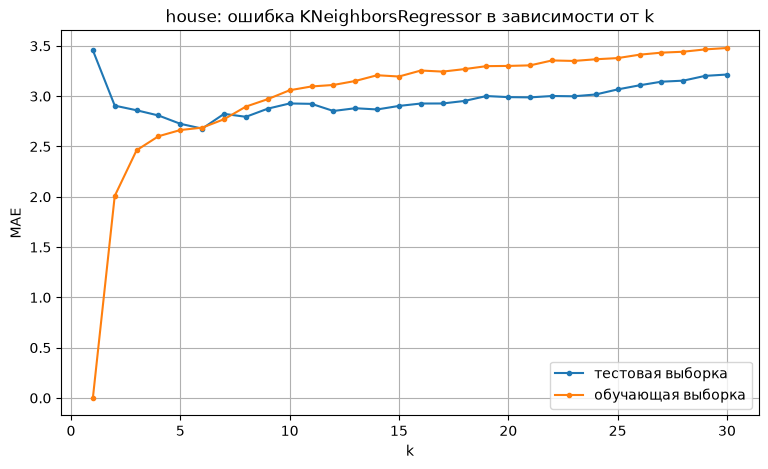

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, mae_test, marker=".", label="тестовая выборка")
plt.plot(k_values, mae_train, marker=".", label="обучающая выборка")
plt.xlabel("k")
plt.ylabel("MAE")
plt.title("house: ошибка KNeighborsRegressor в зависимости от k")
plt.legend()
plt.grid(True)
plt.show()

При `k = 1` ошибка на обучающей выборке равна нулю (ближайший сосед объекта — он сам), а на тесте она самая
большая, 3.46 — классическое переобучение. С ростом `k` прогноз усредняется по большему числу соседей,
тестовая ошибка падает до минимума 2.68 при k = 6, а потом снова начинает расти (3.22 при k = 30): соседей
берем уже слишком много и модель сползает к предсказанию средней цены. Минимум тестовой MAE и есть
оптимальное `k`, обучающая кривая для этого не годится — она монотонно растет и советовала бы k = 1.

### Метрики и прогноз для лучшего k

In [36]:
reg = KNeighborsRegressor(n_neighbors=best_k)
reg.fit(Xh_train_n, Yh_train)
pred_h = reg.predict(Xh_test_n)

print("k =", best_k)
print("MAE  =", mean_absolute_error(Yh_test, pred_h))
print("MSE  =", mean_squared_error(Yh_test, pred_h))
print("RMSE =", np.sqrt(mean_squared_error(Yh_test, pred_h)))
print("R2   =", r2_score(Yh_test, pred_h))

k = 6
MAE  = 2.677521929824562
MSE  = 19.603755482456148
RMSE = 4.427612842430574
R2   = 0.7369085885768776


In [37]:
pd.DataFrame({
    "правильный ответ": Yh_test[:10],
    "прогноз": pred_h[:10].round(2),
    "разница": (Yh_test[:10] - pred_h[:10]).round(2),
})

,правильный ответ,прогноз,разница
0,23.6,24.78,-1.18
1,32.4,28.08,4.32
2,13.6,21.35,-7.75
3,22.8,21.48,1.32
4,16.1,16.48,-0.38
5,20.0,23.82,-3.82
6,17.8,19.77,-1.97
7,14.0,17.30,-3.30
8,19.6,19.05,0.55
9,16.8,21.65,-4.85


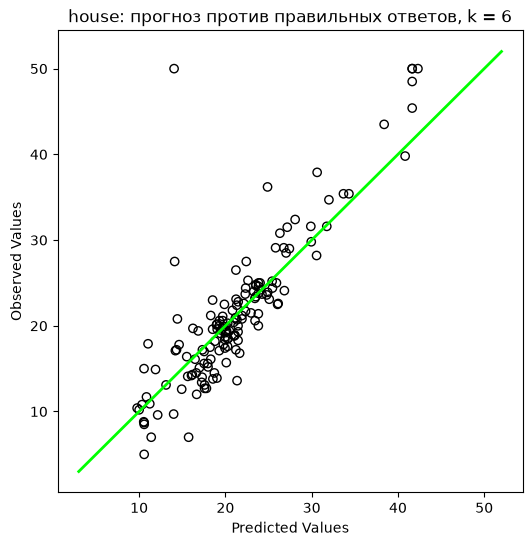

In [38]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_h, Yh_test, facecolors="none", edgecolors="black")

lims = [min(pred_h.min(), Yh_test.min()) - 2, max(pred_h.max(), Yh_test.max()) + 2]
plt.plot(lims, lims, color="lime", linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Observed Values")
plt.title("house: прогноз против правильных ответов, k = " + str(best_k))
plt.show()

Точки в основном держатся около зеленой прямой, то есть прогноз разумный: MAE = 2.68 при средней цене 22.5,
это около 12% ошибки, $R^2 = 0.74$. Хуже всего модель работает на самых дорогих домах (правый верхний угол,
цена 50) — там она систематически занижает цену: прогноз усредняется по соседям, а таких дорогих домов
в выборке мало и соседями им достаются дома подешевле.

**Общий вывод.** Своя реализация kNN дает те же прогнозы, что и `KNeighborsClassifier`, — метод действительно
сводится к "посчитать расстояния, взять k ближайших, проголосовать". Гиперпараметр `k` управляет
переобучением: маленькое `k` запоминает шум, большое — размывает ответ до среднего, а лучшее значение лежит
в середине диапазона и подбирается по графику (k = 9 на iris, 12 на breast cancer, 6 на house). Выбор метрики
влияет слабее — разница между евклидовым и манхэттенским расстоянием пара процентов, — зато масштабирование
признаков для kNN обязательно: на breast cancer оно поднимает точность сильнее, чем любой подбор `k`.